# Set Cover: MomentumBuilder vs. Phased vs. Merged

This notebook evaluates three approaches across **12 distinct 9-qubit Set Cover instances**:

1. **`MomentumBuilder` (no SA)**: Grows the ansatz over N momentum layers with no further parameter optimisation.
2. **`momentum_sa_phased`**: Runs MomentumBuilder for N iterations, *then* runs Simulated Annealing on all parameters at once.
3. **`momentum_sa_merged`**: Interleaves growth and SA — after each momentum layer is added, SA runs immediately on the current parameter set.

Each approach is run for **5 trials per Hamiltonian**. Results are aggregated (mean ± std) and compared per instance.

In [6]:
import sys
import os
import time
import numpy as np
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit, transpile
from qiskit.circuit import Parameter
from qiskit.primitives import StatevectorEstimator as Estimator
from qiskit.quantum_info import SparsePauliOp
from qiskit_aer import AerSimulator

# --- Path Setup ---
vqa_root = os.path.abspath(os.path.join('../../../../'))
if vqa_root not in sys.path:
    sys.path.insert(0, vqa_root)

ansatz_pruning_dir = os.path.abspath(os.path.join('../../../'))
if ansatz_pruning_dir not in sys.path:
    sys.path.insert(0, ansatz_pruning_dir)

from AnsatzPruning import MomentumMonteCarlo, MomentumBuilder

print('Imports OK')

Imports OK


## 1. Set Cover Hamiltonians

Twelve distinct 9-qubit Set Cover instances (9 subsets = 9 qubits each).  
All instances are constructed so that at least one valid cover exists (ground state energy = 0).

In [7]:
def get_subset_Hamiltonian(universe, subsets):
    num_subsets = len(subsets)
    total_op = SparsePauliOp(["I" * num_subsets], coeffs=[0.0])
    for element in universe:
        relevant_indices = [i for i, s in enumerate(subsets) if element in s]
        pauli_id = "I" * num_subsets
        total_op += SparsePauliOp([pauli_id], coeffs=[1.0])
        for idx in relevant_indices:
            z_str = ["I"] * num_subsets
            z_str[num_subsets - 1 - idx] = "Z"
            total_op += SparsePauliOp(["".join(z_str)], coeffs=[0.5])
            total_op += SparsePauliOp([pauli_id], coeffs=[-0.5])
        relevant_indices.sort()
        for i_idx in range(len(relevant_indices)):
            for j_idx in range(i_idx + 1, len(relevant_indices)):
                u, v = relevant_indices[i_idx], relevant_indices[j_idx]
                total_op += SparsePauliOp([pauli_id], coeffs=[0.5])
                z_u = ["I"] * num_subsets; z_u[num_subsets - 1 - u] = "Z"
                total_op += SparsePauliOp(["".join(z_u)], coeffs=[-0.5])
                z_v = ["I"] * num_subsets; z_v[num_subsets - 1 - v] = "Z"
                total_op += SparsePauliOp(["".join(z_v)], coeffs=[-0.5])
                z_uv = ["I"] * num_subsets
                z_uv[num_subsets - 1 - u] = "Z"; z_uv[num_subsets - 1 - v] = "Z"
                total_op += SparsePauliOp(["".join(z_uv)], coeffs=[0.5])
    return total_op.simplify()


# --- 12 distinct 9-qubit instances ---
# All are verified to have at least one valid cover (ground state energy = 0)
INSTANCES = {
    # ---- universe size 6 ----
    "A: pairs + triples (u=6)": {
        "universe": [1, 2, 3, 4, 5, 6],
        "subsets": [{1,2}, {3,4}, {5,6}, {1,3,5}, {2,4,6}, {1,4}, {2,5}, {3,6}, {1,2,6}],
    },
    "B: chain + cross (u=6)": {
        "universe": [1, 2, 3, 4, 5, 6],
        "subsets": [{1,3}, {2,4}, {5,6}, {1,2,5}, {3,4,6}, {2,3}, {1,6}, {4,5}, {2,6}],
    },
    "C: halves + singles (u=6)": {
        "universe": [1, 2, 3, 4, 5, 6],
        "subsets": [{1,2,3}, {4,5,6}, {1,4}, {2,5}, {3,6}, {1,5}, {2,6}, {3,4}, {1,2,6}],
    },
    # ---- universe size 5 ----
    "D: chain (u=5)": {
        "universe": [1, 2, 3, 4, 5],
        "subsets": [{1,2}, {2,3}, {3,4}, {4,5}, {1,3,5}, {2,4}, {1,4}, {3,5}, {1,2,4}],
    },
    "E: random overlap (u=5)": {
        "universe": [1, 2, 3, 4, 5],
        "subsets": [{1,3}, {2,4}, {3,5}, {1,5}, {2,3}, {1,2,4}, {3,4,5}, {1,2,5}, {2,4,5}],
    },
    # ---- universe size 4 ----
    "F: dense pairs/triples (u=4)": {
        "universe": [1, 2, 3, 4],
        "subsets": [{1,2}, {1,3}, {1,4}, {2,3}, {2,4}, {3,4}, {1,2,3}, {2,3,4}, {1,2,4}],
    },
    # ---- universe size 7 ----
    "G: even split (u=7)": {
        "universe": [1, 2, 3, 4, 5, 6, 7],
        "subsets": [{1,2,3}, {4,5,6,7}, {1,4,7}, {2,5}, {3,6}, {1,5,7}, {2,4,6}, {3,5}, {1,2,7}],
    },
    "H: cross-pairs (u=7)": {
        "universe": [1, 2, 3, 4, 5, 6, 7],
        "subsets": [{1,2,4}, {3,5,7}, {2,6}, {1,4,6}, {3,5}, {2,7}, {1,3,6}, {4,5,7}, {1,2,6}],
    },
    # ---- universe size 8 ----
    "I: quad split (u=8)": {
        "universe": [1, 2, 3, 4, 5, 6, 7, 8],
        "subsets": [{1,2}, {3,4}, {5,6}, {7,8}, {1,3,5,7}, {2,4,6,8}, {1,4,6}, {2,3,7}, {5,8}],
    },
    "J: stripes (u=8)": {
        "universe": [1, 2, 3, 4, 5, 6, 7, 8],
        "subsets": [{1,3,5,7}, {2,4,6,8}, {1,2}, {3,4}, {5,6}, {7,8}, {1,4,7}, {2,5,8}, {3,6}],
    },
    # ---- universe size 9 ----
    "K: 3x3 grid (u=9)": {
        "universe": [1, 2, 3, 4, 5, 6, 7, 8, 9],
        "subsets": [{1,2,3}, {4,5,6}, {7,8,9}, {1,4,7}, {2,5,8}, {3,6,9}, {1,5,9}, {2,4,8}, {3,6,7}],
    },
    "L: singletons + big sets (u=6)": {
        "universe": [1, 2, 3, 4, 5, 6],
        "subsets": [{1}, {2}, {3}, {4}, {5}, {6}, {1,2,3}, {4,5,6}, {1,4}],
    },
}

# Build Hamiltonians and print ground-state info
hamiltonians = {}
ground_energies = {}

for name, cfg in INSTANCES.items():
    H = get_subset_Hamiltonian(cfg["universe"], cfg["subsets"])
    nq = len(cfg["subsets"])
    diag = np.real(np.diag(H.to_matrix()))
    e_min = np.min(diag)
    solutions = np.where(np.isclose(diag, e_min))[0]
    hamiltonians[name] = H
    ground_energies[name] = e_min
    print(f"{name}: {nq} qubits | ground energy = {e_min:.4f} | {len(solutions)} solution(s)")

A: pairs + triples (u=6): 9 qubits | ground energy = 0.0000 | 3 solution(s)
B: chain + cross (u=6): 9 qubits | ground energy = 0.0000 | 4 solution(s)
C: halves + singles (u=6): 9 qubits | ground energy = 0.0000 | 3 solution(s)
D: chain (u=5): 9 qubits | ground energy = 0.0000 | 2 solution(s)
E: random overlap (u=5): 9 qubits | ground energy = 0.0000 | 2 solution(s)
F: dense pairs/triples (u=4): 9 qubits | ground energy = 0.0000 | 3 solution(s)
G: even split (u=7): 9 qubits | ground energy = 0.0000 | 2 solution(s)
H: cross-pairs (u=7): 9 qubits | ground energy = 0.0000 | 1 solution(s)
I: quad split (u=8): 9 qubits | ground energy = 0.0000 | 3 solution(s)
J: stripes (u=8): 9 qubits | ground energy = 0.0000 | 3 solution(s)
K: 3x3 grid (u=9): 9 qubits | ground energy = 0.0000 | 3 solution(s)
L: singletons + big sets (u=6): 9 qubits | ground energy = 0.0000 | 5 solution(s)


## 2. Helpers

In [8]:
estimator = Estimator()
simulator = AerSimulator(method='statevector')

def make_initial_ansatz(num_qubits):
    params_symbols = [Parameter(f'a{i}') for i in range(num_qubits)]
    circuit = QuantumCircuit(num_qubits)
    ansatz = QuantumCircuit(num_qubits)
    for i in range(num_qubits):
        ansatz.rx(params_symbols[i], i)
    return circuit, ansatz, [1.0] * num_qubits, list(range(num_qubits))

def sv_energy(circ, params, H):
    """Bind params, run statevector, return expectation value."""
    bound = circ.assign_parameters(params)
    bound.save_statevector()
    sv = simulator.run(transpile(bound, simulator)).result().get_statevector()
    return float(np.real(sv.expectation_value(H)))

print('Helpers ready.')

Helpers ready.


## 3. Run 5 Trials per Approach for Each Hamiltonian

Each trial re-initialises the ansatz from scratch to avoid state carry-over.  
**12 instances × 3 methods × 5 trials** = 180 total runs.

In [9]:
NUM_TRIALS = 5
ITERS = 3
OPT_RUNS = 200
NUM_QUBITS = 9  # all instances are 9-qubit

# results[instance_name] = dict of energy/time arrays
results = {}

for inst_name, H in hamiltonians.items():
    print(f"\n{'='*65}")
    print(f"  {inst_name}")
    print(f"{'='*65}")

    observables_list = [*H.paulis, H]
    phased_energies, phased_times = [], []
    merged_energies, merged_times = [], []
    mb_energies,     mb_times     = [], []

    for trial in range(1, NUM_TRIALS + 1):
        print(f'  Trial {trial}/{NUM_TRIALS}', end=' ... ', flush=True)

        # --- Phased ---
        circuit_p, ansatz_p, params_p, inds_p = make_initial_ansatz(NUM_QUBITS)
        t0 = time.perf_counter()
        _, _, e_phased = MomentumMonteCarlo.momentum_sa_phased(
            params_p, inds_p, ansatz_p, circuit_p, H, estimator,
            beta1=0.9, beta2=0.99, iters=ITERS, optimization_runs=OPT_RUNS
        )
        t_phased = time.perf_counter() - t0
        phased_energies.append(e_phased)
        phased_times.append(t_phased)

        # --- Merged ---
        circuit_m, ansatz_m, params_m, inds_m = make_initial_ansatz(NUM_QUBITS)
        t0 = time.perf_counter()
        _, _, e_merged = MomentumMonteCarlo.momentum_sa_merged(
            params_m, inds_m, ansatz_m, circuit_m, H, estimator,
            beta1=0.9, beta2=0.99, iters=ITERS, optimization_runs=OPT_RUNS
        )
        t_merged = time.perf_counter() - t0
        merged_energies.append(e_merged)
        merged_times.append(t_merged)

        # --- Plain MomentumBuilder (no SA) ---
        circuit_b, ansatz_b, params_b, inds_b = make_initial_ansatz(NUM_QUBITS)
        t0 = time.perf_counter()
        mb_circuit = MomentumBuilder.MomentumBuilder(
            params_b, inds_b, ansatz_b, circuit_b, observables_list, estimator,
            0.9, 0.99, iters=ITERS
        )
        t_mb = time.perf_counter() - t0
        mb_num_params = len(mb_circuit.parameters)
        e_mb = sv_energy(mb_circuit, np.ones(mb_num_params), H)
        mb_energies.append(e_mb)
        mb_times.append(t_mb)

        print(f'Phased={e_phased:.4f} ({t_phased:.1f}s)  '
              f'Merged={e_merged:.4f} ({t_merged:.1f}s)  '
              f'MB={e_mb:.4f} ({t_mb:.1f}s)')

    results[inst_name] = {
        "phased_energies": np.array(phased_energies),
        "merged_energies": np.array(merged_energies),
        "mb_energies":     np.array(mb_energies),
        "phased_times":    np.array(phased_times),
        "merged_times":    np.array(merged_times),
        "mb_times":        np.array(mb_times),
    }

print('\nAll trials complete.')


  A: pairs + triples (u=6)
  Trial 1/5 ... Energy after MomentumBuilder:  8.432785833565145
Energy after MomentumBuilder and Simulated Annealing (SA), two-phased:  2.086479185634777
Energy after merged MB and SA:  0.41676413952719327
Phased=2.0865 (6.9s)  Merged=0.4168 (13.7s)  MB=8.4328 (1.2s)
  Trial 2/5 ... Energy after MomentumBuilder:  8.432785833565145
Energy after MomentumBuilder and Simulated Annealing (SA), two-phased:  2.307090696956601
Energy after merged MB and SA:  2.3534626403516086
Phased=2.3071 (6.5s)  Merged=2.3535 (12.5s)  MB=8.4328 (1.3s)
  Trial 3/5 ... Energy after MomentumBuilder:  8.432785833565145
Energy after MomentumBuilder and Simulated Annealing (SA), two-phased:  2.2820669700838576
Energy after merged MB and SA:  0.4404722303065802
Phased=2.2821 (6.4s)  Merged=0.4405 (13.4s)  MB=8.4328 (1.2s)
  Trial 4/5 ... Energy after MomentumBuilder:  8.432785833565145
Energy after MomentumBuilder and Simulated Annealing (SA), two-phased:  2.2709175960417065
Energy aft

## 4. Comparison Summary & Charts (per Instance)


A: pairs + triples (u=6)
Method                        Mean Energy  Std Energy  Mean Time
---------------------------------------------------------------
MomentumBuilder (no SA)            8.4328      0.0000      1.27s
momentum_sa_phased                 2.0068      0.4663      6.60s
momentum_sa_merged                 0.9684      0.7878     14.02s
Classical ground state             0.0000           -          -


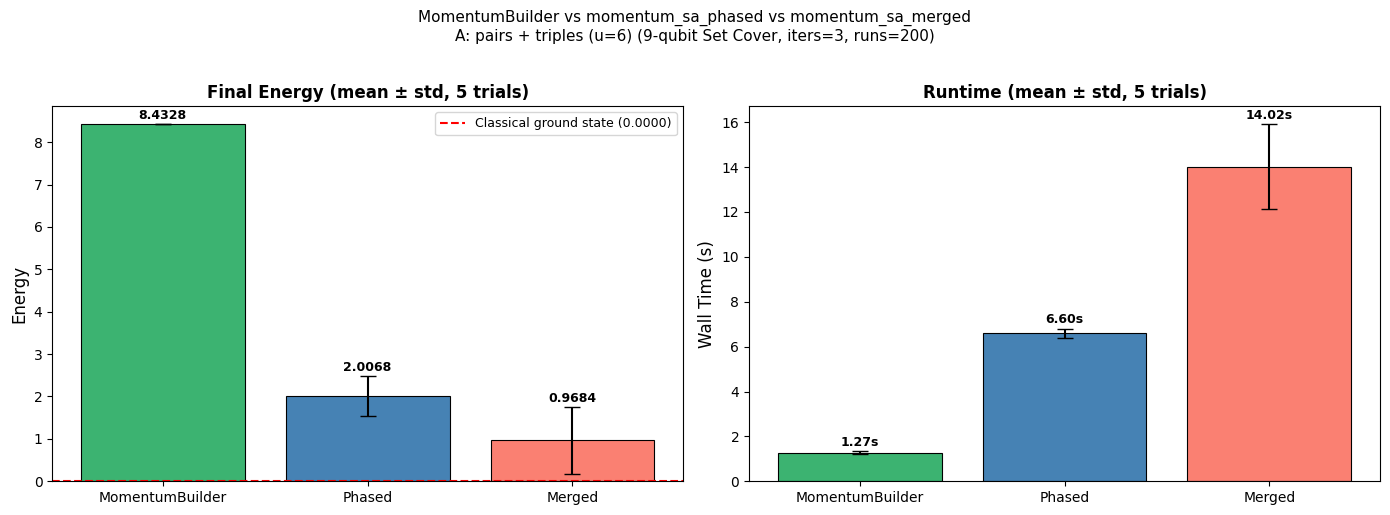


B: chain + cross (u=6)
Method                        Mean Energy  Std Energy  Mean Time
---------------------------------------------------------------
MomentumBuilder (no SA)            7.7960      0.0000      1.43s
momentum_sa_phased                 2.9373      0.6704      7.70s
momentum_sa_merged                 1.7997      0.6619     15.23s
Classical ground state             0.0000           -          -


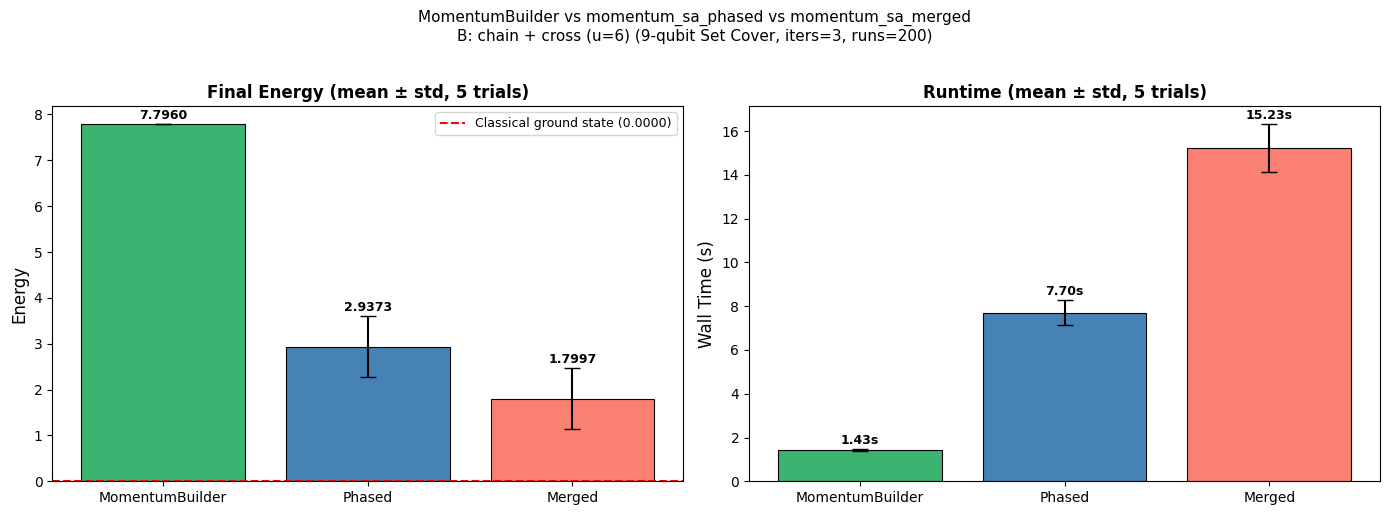


C: halves + singles (u=6)
Method                        Mean Energy  Std Energy  Mean Time
---------------------------------------------------------------
MomentumBuilder (no SA)           12.1975      0.0000      1.34s
momentum_sa_phased                 2.0306      0.3286      6.94s
momentum_sa_merged                 1.7932      0.6637     13.67s
Classical ground state             0.0000           -          -


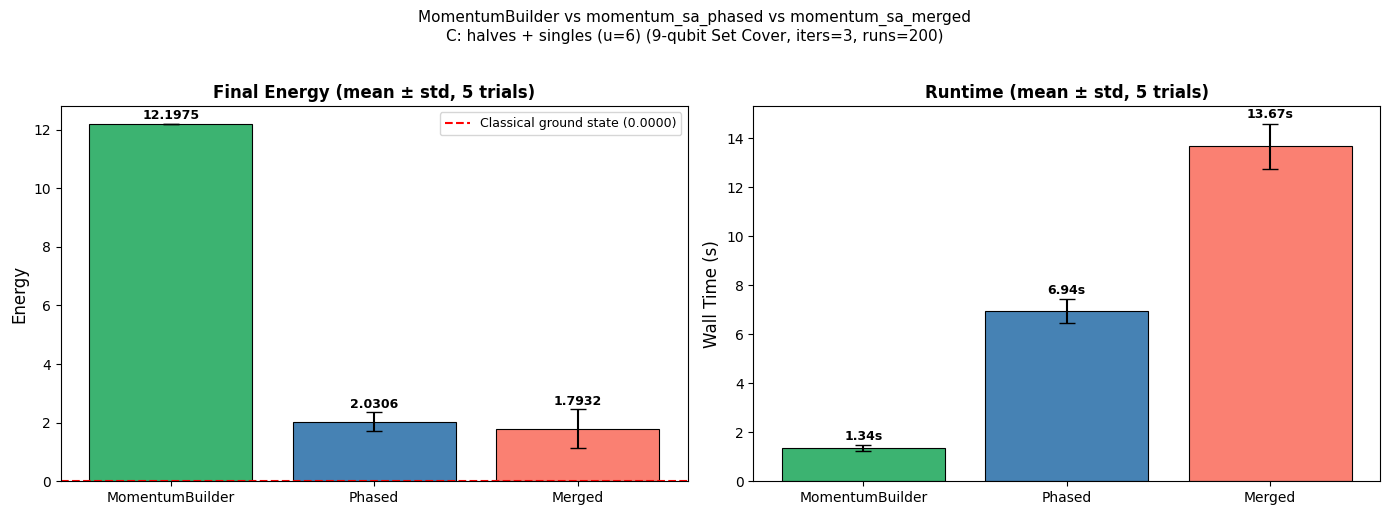


D: chain (u=5)
Method                        Mean Energy  Std Energy  Mean Time
---------------------------------------------------------------
MomentumBuilder (no SA)            9.6034      0.0000      1.34s
momentum_sa_phased                 1.7235      0.5240      7.47s
momentum_sa_merged                 1.1804      1.0401     13.99s
Classical ground state             0.0000           -          -


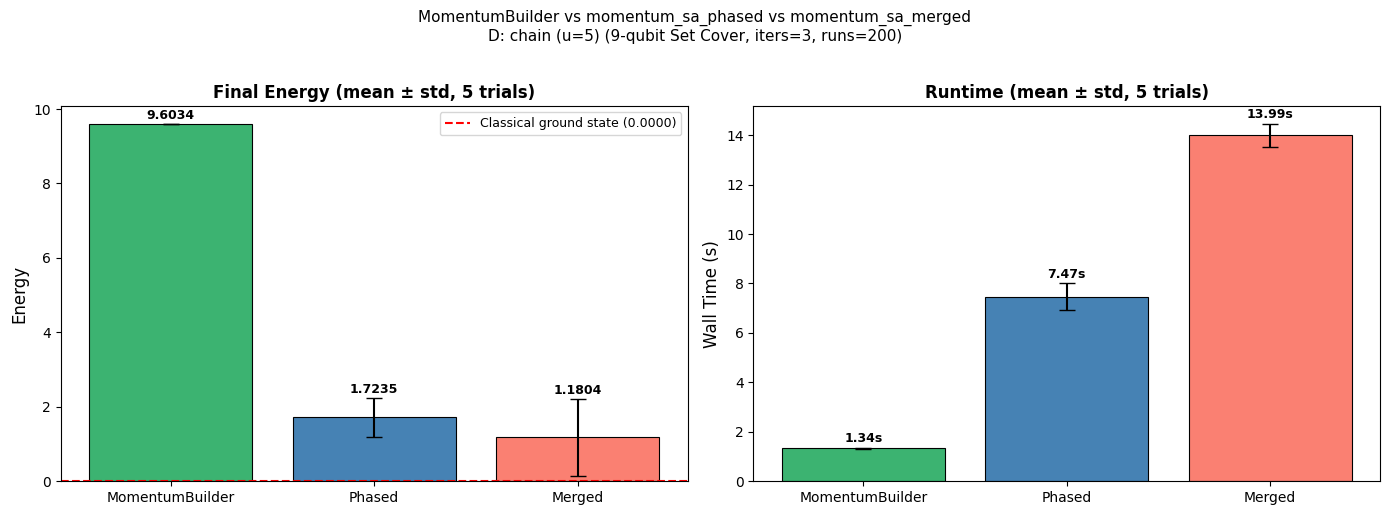


E: random overlap (u=5)
Method                        Mean Energy  Std Energy  Mean Time
---------------------------------------------------------------
MomentumBuilder (no SA)           16.4683      0.0000      1.49s
momentum_sa_phased                 3.5185      0.5784      8.12s
momentum_sa_merged                 2.3707      0.3555     14.98s
Classical ground state             0.0000           -          -


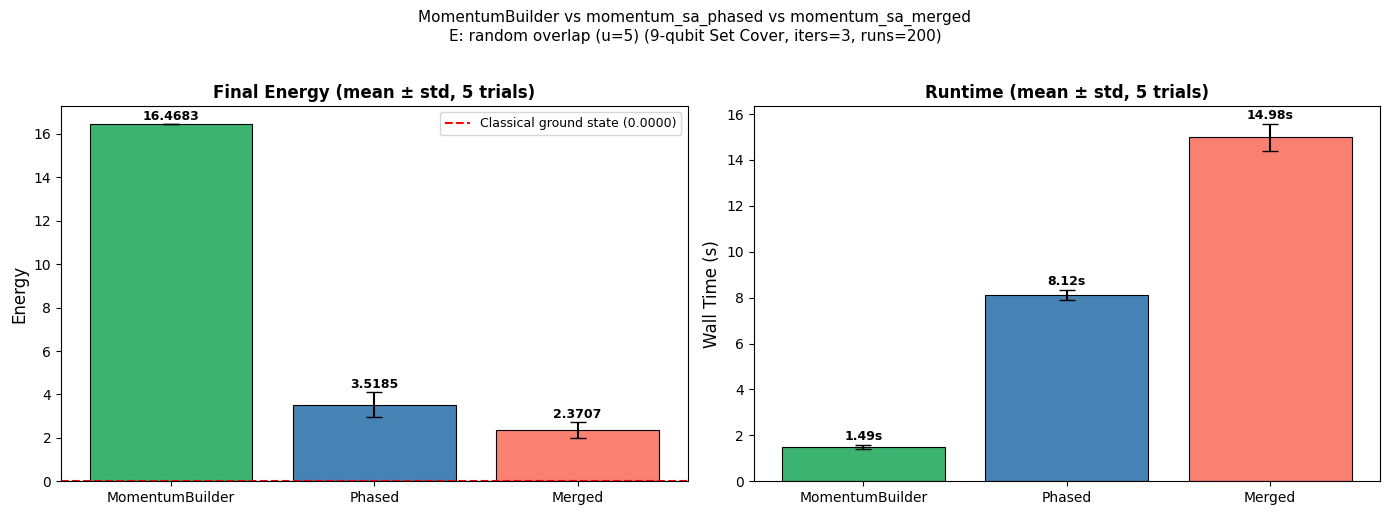


F: dense pairs/triples (u=4)
Method                        Mean Energy  Std Energy  Mean Time
---------------------------------------------------------------
MomentumBuilder (no SA)           17.3373      0.0000      1.89s
momentum_sa_phased                 2.4204      0.3301      9.08s
momentum_sa_merged                 1.8407      0.3299     16.54s
Classical ground state             0.0000           -          -


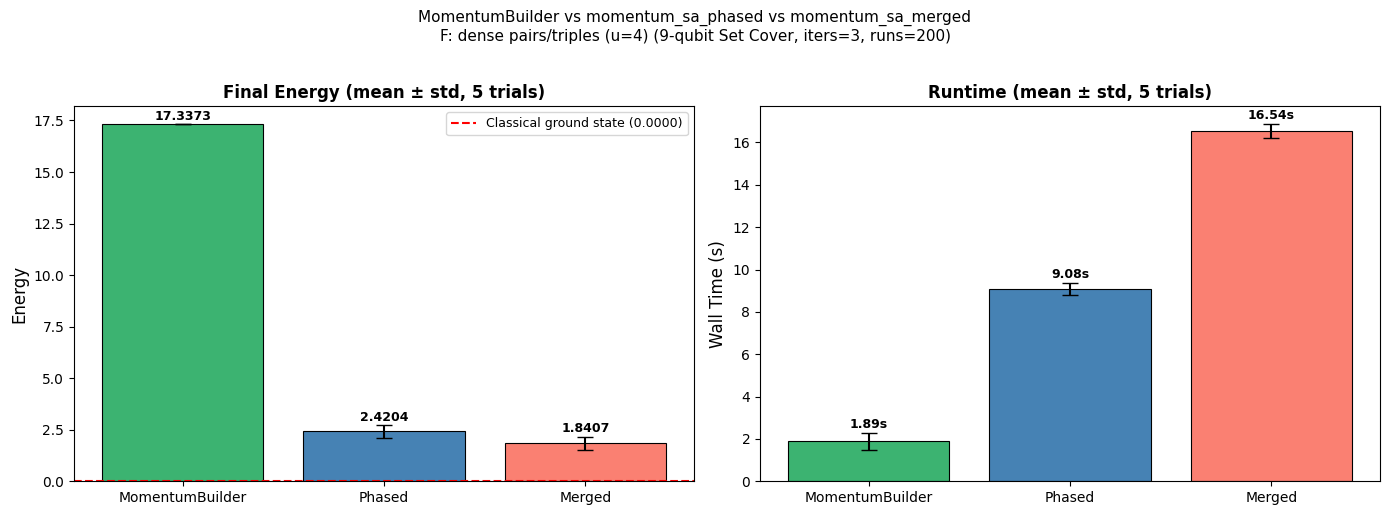


G: even split (u=7)
Method                        Mean Energy  Std Energy  Mean Time
---------------------------------------------------------------
MomentumBuilder (no SA)           13.5757      0.0000      1.47s
momentum_sa_phased                 2.6211      0.3944      7.90s
momentum_sa_merged                 1.9444      0.3824     15.93s
Classical ground state             0.0000           -          -


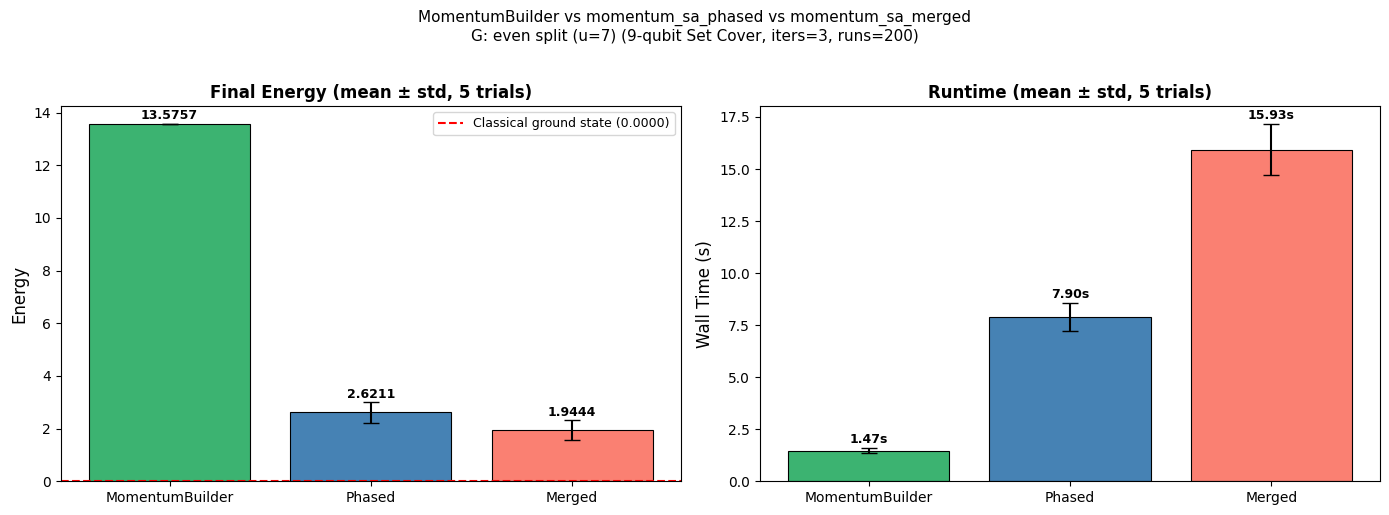


H: cross-pairs (u=7)
Method                        Mean Energy  Std Energy  Mean Time
---------------------------------------------------------------
MomentumBuilder (no SA)           11.3019      0.0000      1.29s
momentum_sa_phased                 2.8344      0.7455      6.28s
momentum_sa_merged                 2.0661      0.7493     12.64s
Classical ground state             0.0000           -          -


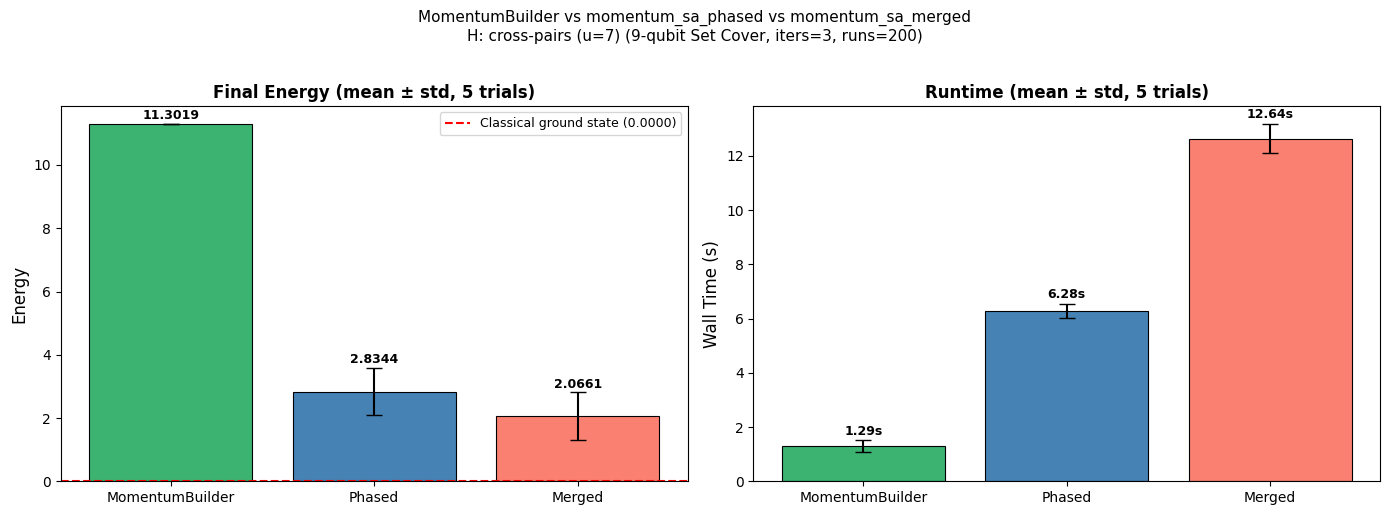


I: quad split (u=8)
Method                        Mean Energy  Std Energy  Mean Time
---------------------------------------------------------------
MomentumBuilder (no SA)            7.9347      0.0000      1.29s
momentum_sa_phased                 2.4572      1.4695      7.29s
momentum_sa_merged                 1.7101      0.9260     13.79s
Classical ground state             0.0000           -          -


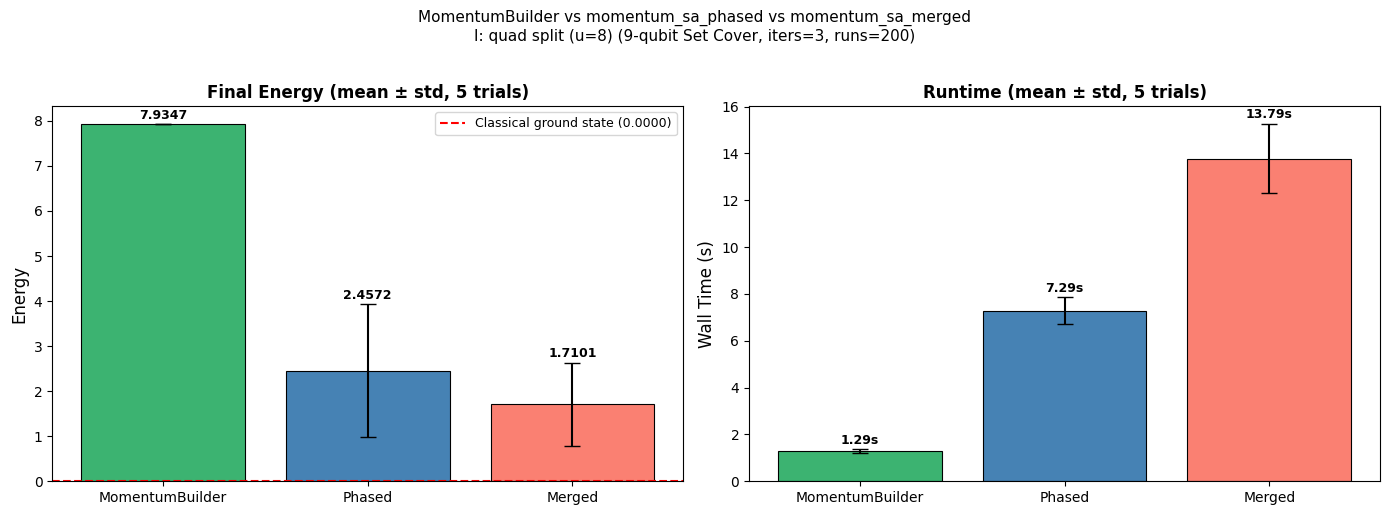


J: stripes (u=8)
Method                        Mean Energy  Std Energy  Mean Time
---------------------------------------------------------------
MomentumBuilder (no SA)           12.4296      0.0000      1.36s
momentum_sa_phased                 3.1342      0.6820      6.83s
momentum_sa_merged                 1.4871      1.0464     13.17s
Classical ground state             0.0000           -          -


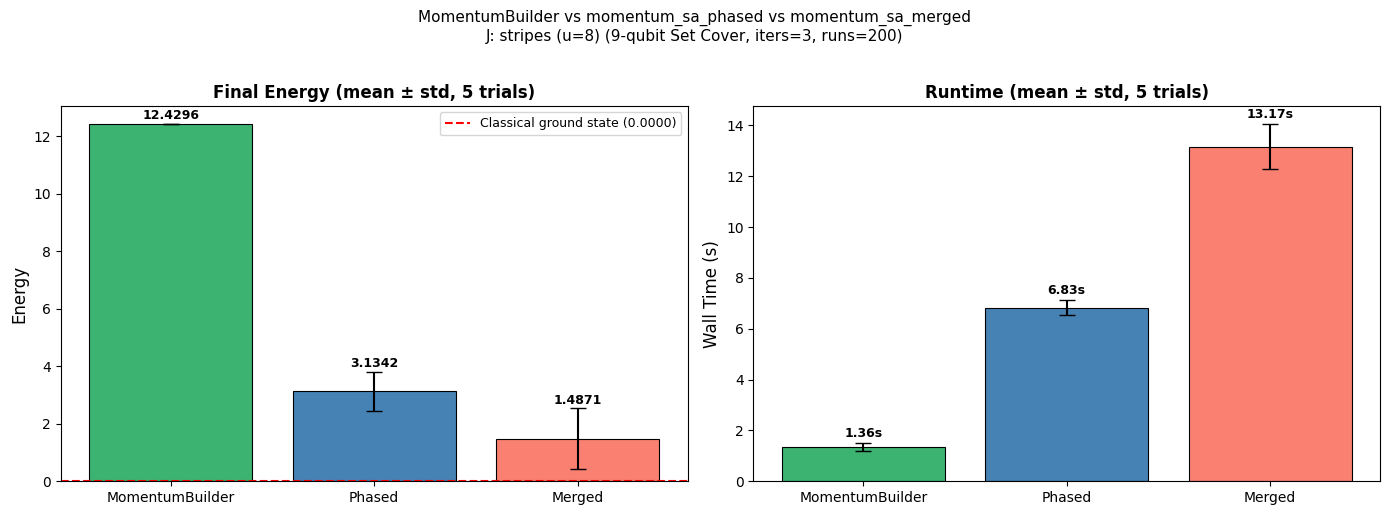


K: 3x3 grid (u=9)
Method                        Mean Energy  Std Energy  Mean Time
---------------------------------------------------------------
MomentumBuilder (no SA)           10.7781      0.0000      1.31s
momentum_sa_phased                 3.2118      1.3958      7.39s
momentum_sa_merged                 1.7906      1.3815     13.86s
Classical ground state             0.0000           -          -


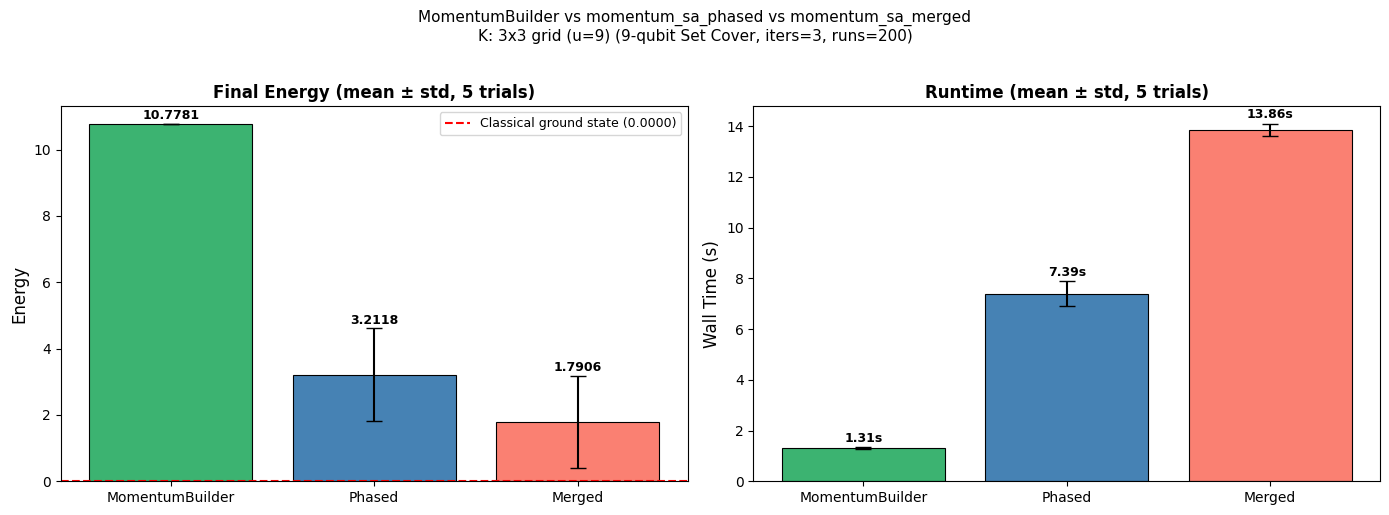


L: singletons + big sets (u=6)
Method                        Mean Energy  Std Energy  Mean Time
---------------------------------------------------------------
MomentumBuilder (no SA)            4.4390      0.0000      0.68s
momentum_sa_phased                 1.9518      0.2796      3.60s
momentum_sa_merged                 1.5323      0.2511      6.89s
Classical ground state             0.0000           -          -


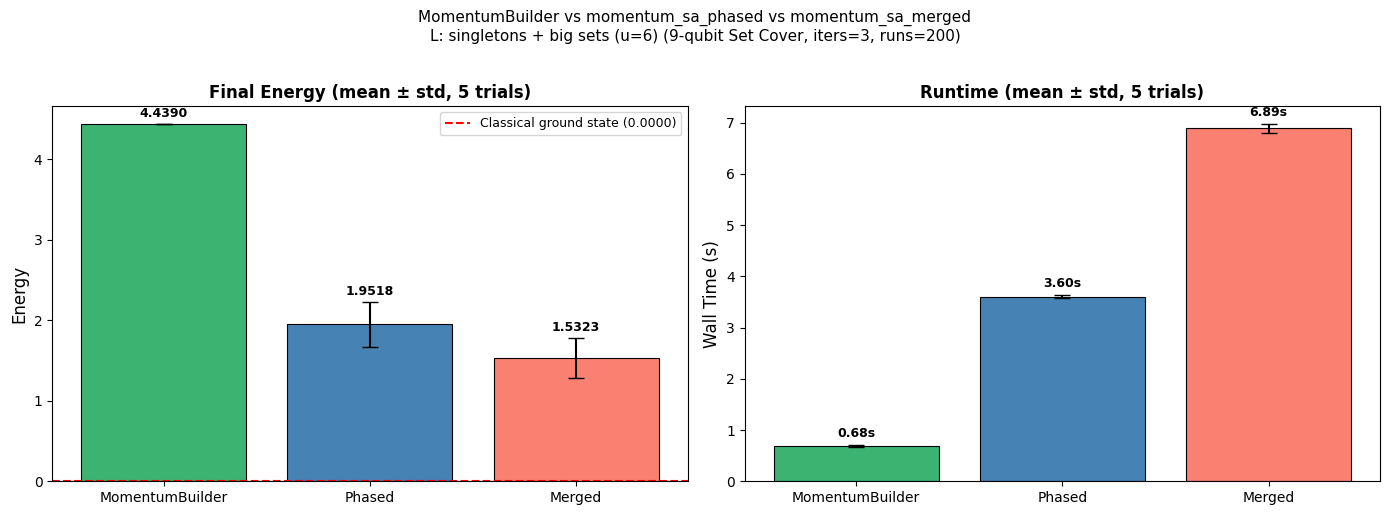

In [10]:
methods = ['MomentumBuilder', 'Phased', 'Merged']
colors  = ['mediumseagreen', 'steelblue', 'salmon']

for inst_name, r in results.items():
    pe = r["phased_energies"]
    me = r["merged_energies"]
    mb = r["mb_energies"]
    pt = r["phased_times"]
    mt = r["merged_times"]
    bt = r["mb_times"]
    e_gs = ground_energies[inst_name]

    print(f'\n{inst_name}')
    print('=' * 70)
    print(f'{"Method":<28} {"Mean Energy":>12} {"Std Energy":>11} {"Mean Time":>10}')
    print('-' * 63)
    print(f'{"MomentumBuilder (no SA)":<28} {mb.mean():>12.4f} {mb.std():>11.4f} {bt.mean():>9.2f}s')
    print(f'{"momentum_sa_phased":<28} {pe.mean():>12.4f} {pe.std():>11.4f} {pt.mean():>9.2f}s')
    print(f'{"momentum_sa_merged":<28} {me.mean():>12.4f} {me.std():>11.4f} {mt.mean():>9.2f}s')
    print(f'{"Classical ground state":<28} {e_gs:>12.4f} {"-":>11} {"-":>10}')

    mean_e = [mb.mean(), pe.mean(), me.mean()]
    std_e  = [mb.std(),  pe.std(),  me.std()]
    mean_t = [bt.mean(), pt.mean(), mt.mean()]
    std_t  = [bt.std(),  pt.std(),  mt.std()]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    # -- Energy chart --
    bars1 = ax1.bar(methods, mean_e, yerr=std_e, capsize=6,
                    color=colors, edgecolor='black', linewidth=0.8)
    ax1.axhline(e_gs, color='red', linestyle='--', linewidth=1.5,
                label=f'Classical ground state ({e_gs:.4f})')
    for bar, m, s in zip(bars1, mean_e, std_e):
        ax1.text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + s + 0.05,
                 f'{m:.4f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
    ax1.set_ylabel('Energy', fontsize=12)
    ax1.set_title(f'Final Energy (mean \u00b1 std, {NUM_TRIALS} trials)', fontsize=12, fontweight='bold')
    ax1.legend(fontsize=9)
    ax1.set_ylim(bottom=0)

    # -- Runtime chart --
    bars2 = ax2.bar(methods, mean_t, yerr=std_t, capsize=6,
                    color=colors, edgecolor='black', linewidth=0.8)
    for bar, m, s in zip(bars2, mean_t, std_t):
        ax2.text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + s + 0.1,
                 f'{m:.2f}s', ha='center', va='bottom', fontsize=9, fontweight='bold')
    ax2.set_ylabel('Wall Time (s)', fontsize=12)
    ax2.set_title(f'Runtime (mean \u00b1 std, {NUM_TRIALS} trials)', fontsize=12, fontweight='bold')
    ax2.set_ylim(bottom=0)

    plt.suptitle(f'MomentumBuilder vs momentum_sa_phased vs momentum_sa_merged\n'
                 f'{inst_name} (9-qubit Set Cover, iters={ITERS}, runs={OPT_RUNS})',
                 fontsize=11, y=1.02)
    plt.tight_layout()
    plt.show()

## 5. Aggregate Summary Across All Instances

===== AGGREGATE (all instances combined) =====
Method                        Mean Energy  Std Energy  Mean Time
---------------------------------------------------------------
MomentumBuilder (no SA)           11.0245      3.5539      1.35s
momentum_sa_phased                 2.5706      0.9325      7.10s
momentum_sa_merged                 1.7070      0.8668     13.73s


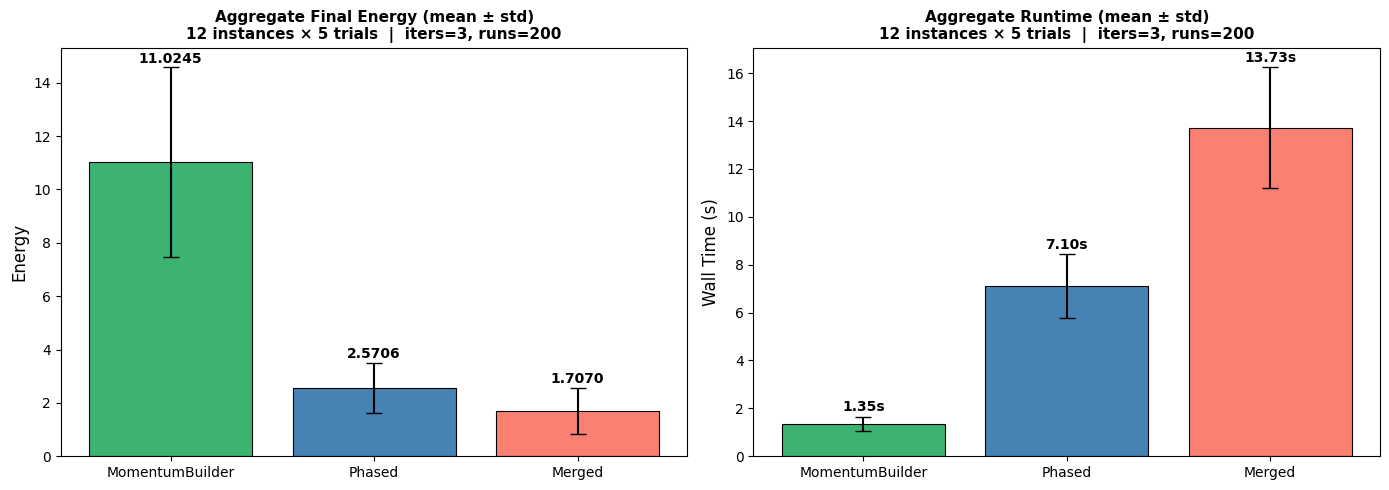

In [12]:
all_mb = np.concatenate([r["mb_energies"]     for r in results.values()])
all_pe = np.concatenate([r["phased_energies"] for r in results.values()])
all_me = np.concatenate([r["merged_energies"] for r in results.values()])
all_mb_t = np.concatenate([r["mb_times"]     for r in results.values()])
all_pe_t = np.concatenate([r["phased_times"] for r in results.values()])
all_me_t = np.concatenate([r["merged_times"] for r in results.values()])

print('===== AGGREGATE (all instances combined) =====')
print(f'{"Method":<28} {"Mean Energy":>12} {"Std Energy":>11} {"Mean Time":>10}')
print('-' * 63)
print(f'{"MomentumBuilder (no SA)":<28} {all_mb.mean():>12.4f} {all_mb.std():>11.4f} {all_mb_t.mean():>9.2f}s')
print(f'{"momentum_sa_phased":<28} {all_pe.mean():>12.4f} {all_pe.std():>11.4f} {all_pe_t.mean():>9.2f}s')
print(f'{"momentum_sa_merged":<28} {all_me.mean():>12.4f} {all_me.std():>11.4f} {all_me_t.mean():>9.2f}s')

mean_e = [all_mb.mean(), all_pe.mean(), all_me.mean()]
std_e  = [all_mb.std(),  all_pe.std(),  all_me.std()]
mean_t = [all_mb_t.mean(), all_pe_t.mean(), all_me_t.mean()]
std_t  = [all_mb_t.std(),  all_pe_t.std(),  all_me_t.std()]
colors  = ['mediumseagreen', 'steelblue', 'salmon']
methods = ['MomentumBuilder', 'Phased', 'Merged']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# -- Energy chart --
bars1 = ax1.bar(methods, mean_e, yerr=std_e, capsize=6,
                color=colors, edgecolor='black', linewidth=0.8)
for bar, m, s in zip(bars1, mean_e, std_e):
    ax1.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + s + 0.05,
             f'{m:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax1.set_ylabel('Energy', fontsize=12)
ax1.set_title(
    f'Aggregate Final Energy (mean \u00b1 std)\n'
    f'12 instances \u00d7 {NUM_TRIALS} trials  |  iters={ITERS}, runs={OPT_RUNS}',
    fontsize=11, fontweight='bold'
)
ax1.set_ylim(bottom=0)

# -- Runtime chart --
bars2 = ax2.bar(methods, mean_t, yerr=std_t, capsize=6,
                color=colors, edgecolor='black', linewidth=0.8)
for bar, m, s in zip(bars2, mean_t, std_t):
    ax2.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + s + 0.1,
             f'{m:.2f}s', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax2.set_ylabel('Wall Time (s)', fontsize=12)
ax2.set_title(
    f'Aggregate Runtime (mean \u00b1 std)\n'
    f'12 instances \u00d7 {NUM_TRIALS} trials  |  iters={ITERS}, runs={OPT_RUNS}',
    fontsize=11, fontweight='bold'
)
ax2.set_ylim(bottom=0)

plt.tight_layout()
plt.show()